## Figure 7

![title](../assets/Fig7.png)

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import logging
from itertools import combinations
from pathlib import Path

import numpy as np
import scipy
import matplotlib.pyplot as plt
from mycolorpy import colorlist as mcp
from scipy.stats import ttest_rel

sys.path.insert(0, "./prepare_data/")

from common import *

logging.getLogger("matplotlib.font_manager").disabled = True

DATA_PATH = Path("../data")
EXPORT_PATH = Path("../results/Figure7")
EXPORT_PATH.mkdir(exist_ok=True, parents=True)

plt.style.use("./config.mplstyle")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
colors_piyg = mcp.gen_color(cmap="PiYG", n=5)

COLOR_LEGS = {
    "RF": COLORS["blue"],
    "LF": COLORS["vermillion"],
    "RAnt": COLORS["skyblue"],
    "LAnt": COLORS["orange"],
}

COND_COLORS = {
    "airpuff_opto_1s": "black",
    "airpuff_1s": "steelblue",
    "opto_4s": "firebrick",
}
COND_LABELS = {
    "airpuff_opto_1s": "airpuff\nopto",
    "airpuff_1s": "airpuff",
    "opto_4s": "opto",
}
CONDS = ["airpuff_opto_1s", "airpuff_1s", "opto_4s"]

INTERVAL_INDICATORS = {
    "airpuff_opto_1s": [50, 150, 150, 450],
    "airpuff_1s": [50, 150],
    "opto_4s": [50, 450],
}
INT_LABEL_COLORS = {"airpuff": "steelblue", "opto": "firebrick"}

FIGSIZE = {"width": 1.2, "length": 0.9}
TIME_STEP = 0.01
STAT_WINDOW = 30

## Data loading

In [3]:
asteroid_data = load_data(DATA_PATH / "Fig7_asteroid_data.pkl")
negative_data = load_data(DATA_PATH / "Fig7_neg_control_data.pkl")

## Shared helper functions

In [4]:
def calculate_statistics(dist1, dist2, alt="two-sided", paired=True):
    """Wilcoxon (paired) or Mann-Whitney U (unpaired) test."""
    if paired:
        result = scipy.stats.wilcoxon(dist1, dist2, alternative=alt)
    else:
        result = scipy.stats.mannwhitneyu(dist1, dist2, alternative=alt)
    return result.pvalue


def _fly_name(key):
    return "_".join(key.split("_")[:2])


def _add_stim_spans(ax, intervals, exp_type):
    """Shade stimulus intervals with steelblue (airpuff) and firebrick (opto)."""
    int_labels = ["airpuff", "opto"] if "airpuff" in exp_type else ["opto"]
    for i in range(0, len(intervals), 2):
        ax.axvspan(
            intervals[i] * TIME_STEP,
            intervals[i + 1] * TIME_STEP,
            color=INT_LABEL_COLORS[int_labels[i // 2]],
            alpha=0.15,
            lw=0,
        )


def plot_shaded_timeseries(series_list, n_flies, ax, color="black", q_lo=0.2, q_hi=0.8):
    """Plot median timeseries with shaded quantile band and fly count annotation."""
    if not series_list:
        return
    median = np.median(series_list, axis=0)
    q_top  = np.quantile(series_list, q_hi, axis=0)
    q_bot  = np.quantile(series_list, q_lo, axis=0)
    time   = np.arange(len(median)) * TIME_STEP
    ax.plot(time, median, color=color, lw=1)
    ax.fill_between(time, q_top, q_bot, color=color, alpha=0.3, lw=0)
    ax.text(0.08, 0.05, f"n={n_flies}", fontsize=6,
            ha="center", va="center", transform=ax.transAxes)


def collect_fly_stats(exp_data, stat_col, exp_type, intervals, transform=None):
    """Collect per-fly (before, after) median pairs around the stimulus transition."""
    fly_stats = {}
    transition = intervals[1] if exp_type != "opto_4s" else intervals[0]
    for key, df_stim in exp_data.items():
        values = df_stim[stat_col].to_numpy()
        if transform is not None:
            values = transform(values)
        before = np.median(values[transition - STAT_WINDOW : transition])
        after  = np.median(values[transition : transition + STAT_WINDOW])
        fly_stats.setdefault(_fly_name(key), []).append((before, after))
    return fly_stats

## Foreleg–antenna distance (asteroid)

Median ± 20th–80th percentile across valid trials; shaded regions show stimulus intervals.

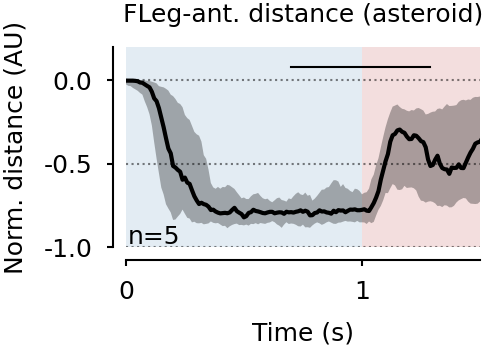

airpuff_opto_1s: 88 valid trials, 5 flies, 0 discarded.


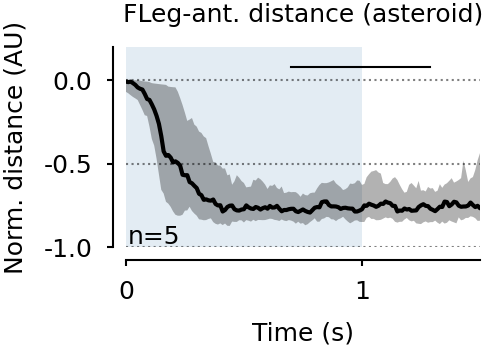

airpuff_1s: 66 valid trials, 5 flies, 0 discarded.


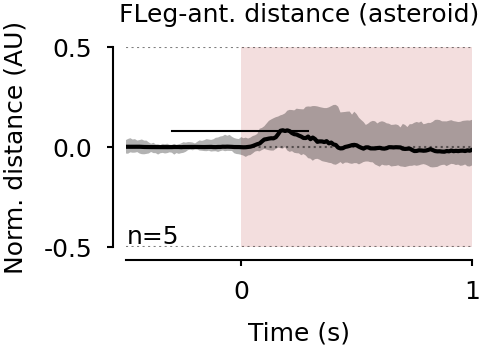

opto_4s: 108 valid trials, 5 flies, 0 discarded.


In [5]:
fly_stats_dist_asteroid = {
    cond: collect_fly_stats(
        asteroid_data.get(cond, {}),
        stat_col="mean_Ant_TiTa_distance",
        exp_type=cond,
        intervals=INTERVAL_INDICATORS[cond],
        transform=lambda v: (v - np.median(v[:50])) / np.median(v[:50]),
    )
    for cond in CONDS
    if cond in asteroid_data
}

with plt.style.context("./config.mplstyle"):
    count_trash = 0

    for exp_type, intervals in INTERVAL_INDICATORS.items():
        exp_data = asteroid_data.get(exp_type, {})
        if not exp_data:
            continue

        distance_list = []
        fly_names_seen = set()

        fig, ax = plt.subplots(
            figsize=(FIGSIZE["width"] * 1.5, FIGSIZE["length"] * 1.5), dpi=300
        )

        # Stat-window indicator line
        transition = intervals[1] if exp_type != "opto_4s" else intervals[0]
        ax.plot(
            np.arange(transition - STAT_WINDOW, transition + STAT_WINDOW) * TIME_STEP,
            np.zeros(STAT_WINDOW * 2) + 0.08,
            color="black", lw=0.5,
        )

        for key, df_stim in exp_data.items():
            initial  = np.median(df_stim["mean_Ant_TiTa_distance"].to_numpy()[:50])
            norm     = (df_stim["mean_Ant_TiTa_distance"] - initial) / initial
            distance = norm.to_numpy()

            distance_list.append(distance)
            fly_names_seen.add(_fly_name(key))

        _add_stim_spans(ax, intervals, exp_type)
        plot_shaded_timeseries(distance_list, len(fly_names_seen), ax)

        ax.set_xticks([0.5, 1.5, 2.5], labels=["0", "1", "2"])
        if exp_type == "opto_4s":
            ax.set_xlim(0.0, 1.5)
            ax.set_ylim(-0.5, 0.5)
            ax.set_yticks([-0.5, 0.0, 0.5], labels=["-0.5", "0.0", "0.5"])
        else:
            ax.set_xlim(0.5, 2.0)
            ax.set_ylim(-1.0, 0.2)
            ax.set_yticks([-1.0, -0.5, 0.0], labels=["-1.0", "-0.5", "0.0"])

        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Norm. distance (AU)")
        ax.yaxis.grid(True, ls=":", lw=0.5, alpha=0.5, color="black")
        ax.set_title("FLeg-ant. distance (asteroid)", fontsize=6)
        ax.spines["left"].set_position(("outward", 3))
        ax.spines["bottom"].set_position(("outward", 3))

        plt.tight_layout()
        fig.savefig(
            EXPORT_PATH / f"Fig7_panelA_{exp_type}_dist_shaded.png",
            bbox_inches="tight", dpi=300,
        )
        plt.show()
        print(f"{exp_type}: {len(distance_list)} valid trials, {len(fly_names_seen)} flies, {count_trash} discarded.")

## Foreleg–antenna distance – per-fly before/after summary (asteroid)

[asteroid dist] airpuff_opto_1s: p=0.02225
[asteroid dist] airpuff_1s: p=0.5833
[asteroid dist] opto_4s: p=0.0004929
[asteroid dist delta] airpuff_opto_1s vs airpuff_1s: p=0.0625
[asteroid dist delta] airpuff_opto_1s vs opto_4s: p=0.0625
[asteroid dist delta] airpuff_1s vs opto_4s: p=0.1875


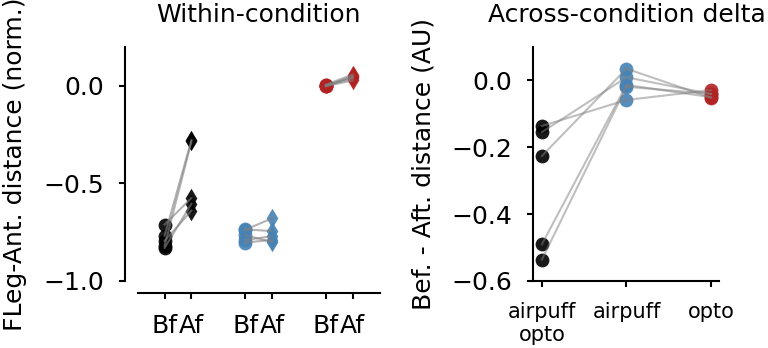

In [6]:
with plt.style.context("./config.mplstyle"):
    fig, (axA, axB) = plt.subplots(
        1, 2,
        figsize=(FIGSIZE["width"] * 2.2, FIGSIZE["length"] * 1.5),
        dpi=300,
        gridspec_kw={"width_ratios": [1.3, 1.0]},
    )

    xpos = 0
    x_positions = []

    for cond in CONDS:
        if cond not in fly_stats_dist_asteroid:
            continue
        before_vals, after_vals = [], []
        for fly in fly_stats_dist_asteroid[cond]:
            arr = np.array(fly_stats_dist_asteroid[cond][fly])
            before_vals.append(np.median(arr[:, 0]))
            after_vals.append(np.median(arr[:, 1]))
        before_vals = np.array(before_vals)
        after_vals  = np.array(after_vals)

        for b, a in zip(before_vals, after_vals):
            axA.plot([xpos, xpos + 1], [b, a], color="gray", alpha=0.6, lw=0.5)
        axA.scatter(np.ones_like(before_vals) * xpos, before_vals,
                    color=COND_COLORS[cond], s=11, lw=0, alpha=0.9)
        axA.scatter(np.ones_like(after_vals) * (xpos + 1), after_vals,
                    color=COND_COLORS[cond], s=11, lw=0, alpha=0.9, marker="d")

        _, p = ttest_rel(after_vals, before_vals)
        print(f"[asteroid dist] {cond}: p={p:.4g}")

        x_positions.extend([xpos, xpos + 1])
        xpos += 3

    axA.set_xticks(x_positions)
    axA.set_xticklabels(["Bf", "Af"] * len(fly_stats_dist_asteroid), rotation=90)
    axA.set_ylabel("FLeg-Ant. distance (norm.)")
    axA.set_xlim(-1, xpos - 1)
    axA.set_ylim(-1.0, 0.2)
    axA.spines[["top", "right"]].set_visible(False)
    axA.spines["left"].set_position(("outward", 3))
    axA.spines["bottom"].set_position(("outward", 3))
    axA.set_title("Within-condition", fontsize=6)

    # Δ across conditions (matched flies)
    fly_sets = [set(fly_stats_dist_asteroid[c].keys()) for c in CONDS if c in fly_stats_dist_asteroid]
    common_flies = sorted(set.intersection(*fly_sets)) if len(fly_sets) > 1 else sorted(fly_sets[0])

    deltas = {}
    for cond in CONDS:
        if cond not in fly_stats_dist_asteroid:
            continue
        d = []
        for fly in common_flies:
            if fly not in fly_stats_dist_asteroid[cond]:
                continue
            arr = np.array(fly_stats_dist_asteroid[cond][fly])
            d.append(np.median(arr[:, 0]) - np.median(arr[:, 1]))
        deltas[cond] = np.array(d)

    conds_present = [c for c in CONDS if c in deltas]
    for i, cond in enumerate(conds_present):
        axB.scatter(np.ones(len(deltas[cond])) * i, deltas[cond],
                    color=COND_COLORS[cond], s=11, lw=0, alpha=0.9)
        if i + 1 < len(conds_present):
            for j in range(len(deltas[cond])):
                axB.plot([i, i + 1],
                         [deltas[cond][j], deltas[conds_present[i + 1]][j]],
                         color="grey", alpha=0.5, lw=0.5)

    for c1, c2 in combinations(conds_present, 2):
        p = calculate_statistics(deltas[c1], deltas[c2])
        print(f"[asteroid dist delta] {c1} vs {c2}: p={p:.4g}")

    axB.set_xticks(range(len(conds_present)))
    axB.set_xticklabels([COND_LABELS[c] for c in conds_present], fontsize=5)
    axB.set_ylabel("Bef. - Aft. distance (AU)")
    axB.set_ylim(-0.6,0.1)
    axB.spines[["top", "right"]].set_visible(False)
    axB.set_title("Across-condition delta", fontsize=6)

    plt.tight_layout()
    fig.savefig(
        EXPORT_PATH / "Fig7_panelB_dist_stats_asteroid.png",
        bbox_inches="tight", dpi=300,
    )
    plt.show()

## Foreleg–antenna distance (negative control)

Same analysis as before for UAS-CsChrimson flies (no Gal4 driver).

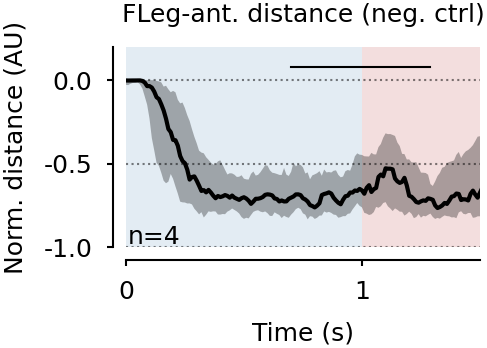

airpuff_opto_1s: 55 valid trials, 4 flies, 0 discarded.


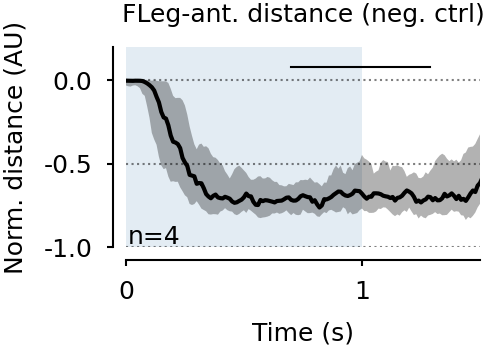

airpuff_1s: 54 valid trials, 4 flies, 0 discarded.


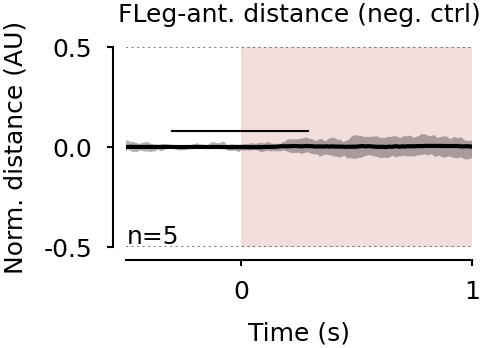

opto_4s: 100 valid trials, 5 flies, 0 discarded.


In [7]:
fly_stats_dist_negative = {
    cond: collect_fly_stats(
        negative_data.get(cond, {}),
        stat_col="mean_Ant_TiTa_distance",
        exp_type=cond,
        intervals=INTERVAL_INDICATORS[cond],
        transform=lambda v: (v - np.median(v[:50])) / np.median(v[:50]),
    )
    for cond in CONDS
    if cond in negative_data
}

with plt.style.context("./config.mplstyle"):
    count_trash = 0

    for exp_type, intervals in INTERVAL_INDICATORS.items():
        exp_data = negative_data.get(exp_type, {})
        if not exp_data:
            continue

        distance_list = []
        fly_names_seen = set()

        fig, ax = plt.subplots(
            figsize=(FIGSIZE["width"] * 1.5, FIGSIZE["length"] * 1.5), dpi=300
        )

        # Stat-window indicator line
        transition = intervals[1] if exp_type != "opto_4s" else intervals[0]
        ax.plot(
            np.arange(transition - STAT_WINDOW, transition + STAT_WINDOW) * TIME_STEP,
            np.zeros(STAT_WINDOW * 2) + 0.08,
            color="black", lw=0.5,
        )

        for key, df_stim in exp_data.items():
            initial  = np.median(df_stim["mean_Ant_TiTa_distance"].to_numpy()[:50])
            norm     = (df_stim["mean_Ant_TiTa_distance"] - initial) / initial
            distance = norm.to_numpy()

            distance_list.append(distance)
            fly_names_seen.add(_fly_name(key))

        _add_stim_spans(ax, intervals, exp_type)
        plot_shaded_timeseries(distance_list, len(fly_names_seen), ax)

        ax.set_xticks([0.5, 1.5, 2.5], labels=["0", "1", "2"])
        if exp_type == "opto_4s":
            ax.set_xlim(0.0, 1.5)
            ax.set_ylim(-0.5, 0.5)
            ax.set_yticks([-0.5, 0.0, 0.5], labels=["-0.5", "0.0", "0.5"])
        else:
            ax.set_xlim(0.5, 2.0)
            ax.set_ylim(-1.0, 0.2)
            ax.set_yticks([-1.0, -0.5, 0.0], labels=["-1.0", "-0.5", "0.0"])

        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Norm. distance (AU)")
        ax.yaxis.grid(True, ls=":", lw=0.5, alpha=0.5, color="black")
        ax.set_title("FLeg-ant. distance (neg. ctrl)", fontsize=6)
        ax.spines["left"].set_position(("outward", 3))
        ax.spines["bottom"].set_position(("outward", 3))

        plt.tight_layout()
        fig.savefig(
            EXPORT_PATH / f"Fig7_panelC_{exp_type}_dist_shaded_neg.png",
            bbox_inches="tight", dpi=300,
        )
        plt.show()
        print(f"{exp_type}: {len(distance_list)} valid trials, {len(fly_names_seen)} flies, {count_trash} discarded.")

## Foreleg–antenna distance – per-fly before/after summary (negative control)

[neg dist] airpuff_opto_1s: p=0.3789
[neg dist] airpuff_1s: p=0.4112
[neg dist] opto_4s: p=0.9751
[neg dist delta] airpuff_opto_1s vs airpuff_1s: p=0.8857
[neg dist delta] airpuff_opto_1s vs opto_4s: p=0.6857
[neg dist delta] airpuff_1s vs opto_4s: p=0.4857


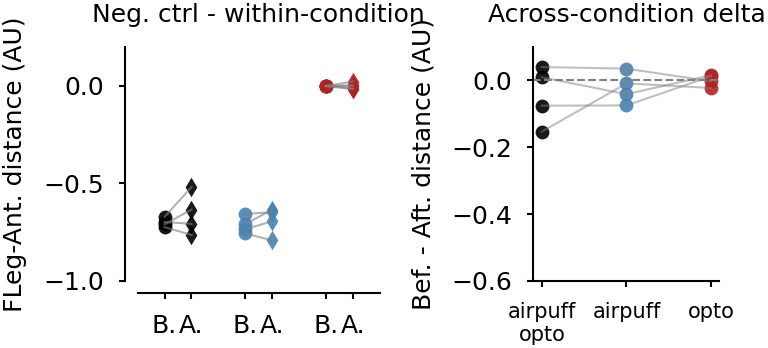

In [8]:
with plt.style.context("./config.mplstyle"):
    fig, (axA, axB) = plt.subplots(
        1, 2,
        figsize=(FIGSIZE["width"] * 2.2, FIGSIZE["length"] * 1.5),
        dpi=300,
        gridspec_kw={"width_ratios": [1.3, 1.0]},
    )

    xpos = 0
    x_positions = []

    for cond in CONDS:
        if cond not in fly_stats_dist_negative:
            continue
        before_vals, after_vals = [], []
        for fly in fly_stats_dist_negative[cond]:
            arr = np.array(fly_stats_dist_negative[cond][fly])
            before_vals.append(np.median(arr[:, 0]))
            after_vals.append(np.median(arr[:, 1]))
        before_vals = np.array(before_vals)
        after_vals  = np.array(after_vals)

        for b, a in zip(before_vals, after_vals):
            axA.plot([xpos, xpos + 1], [b, a], color="gray", alpha=0.6, lw=0.5)
        axA.scatter(np.ones_like(before_vals) * xpos, before_vals,
                    color=COND_COLORS[cond], s=11, lw=0, alpha=0.9)
        axA.scatter(np.ones_like(after_vals) * (xpos + 1), after_vals,
                    color=COND_COLORS[cond], s=11, lw=0, alpha=0.9, marker="d")

        _, p = ttest_rel(after_vals, before_vals)
        print(f"[neg dist] {cond}: p={p:.4g}")

        x_positions.extend([xpos, xpos + 1])
        xpos += 3

    axA.set_xticks(x_positions)
    axA.set_xticklabels(["B.", "A."] * len(fly_stats_dist_negative), rotation=90)
    axA.set_ylabel("FLeg-Ant. distance (AU)")
    axA.set_xlim(-1, xpos - 1)
    axA.set_ylim(-1.0, 0.2)
    axA.spines[["top", "right"]].set_visible(False)
    axA.spines["left"].set_position(("outward", 3))
    axA.spines["bottom"].set_position(("outward", 3))
    axA.set_title("Neg. ctrl - within-condition", fontsize=6)

    fly_sets = [set(fly_stats_dist_negative[c].keys()) for c in CONDS if c in fly_stats_dist_negative]
    common_flies = sorted(set.intersection(*fly_sets)) if len(fly_sets) > 1 else sorted(fly_sets[0])

    deltas = {}
    for cond in CONDS:
        if cond not in fly_stats_dist_negative:
            continue
        d = []
        for fly in common_flies:
            if fly not in fly_stats_dist_negative[cond]:
                continue
            arr = np.array(fly_stats_dist_negative[cond][fly])
            d.append(np.median(arr[:, 0]) - np.median(arr[:, 1]))
        deltas[cond] = np.array(d)

    conds_present = [c for c in CONDS if c in deltas]
    for i, cond in enumerate(conds_present):
        axB.scatter(np.ones(len(deltas[cond])) * i, deltas[cond],
                    color=COND_COLORS[cond], s=11, lw=0, alpha=0.9)
        if i + 1 < len(conds_present):
            for j in range(len(deltas[cond])):
                axB.plot([i, i + 1],
                         [deltas[cond][j], deltas[conds_present[i + 1]][j]],
                         color="grey", alpha=0.5, lw=0.5)

    for c1, c2 in combinations(conds_present, 2):
        p = calculate_statistics(deltas[c1], deltas[c2], paired=False)
        print(f"[neg dist delta] {c1} vs {c2}: p={p:.4g}")

    axB.set_xticks(range(len(conds_present)))
    axB.set_xticklabels([COND_LABELS[c] for c in conds_present], fontsize=5)
    axB.set_ylim(-0.6,0.1)
    axB.set_ylabel("Bef. - Aft. distance (AU)")
    axB.axhline(0, color="grey", lw=0.5, linestyle="--")
    axB.spines[["top", "right"]].set_visible(False)
    axB.set_title("Across-condition delta", fontsize=6)

    plt.tight_layout()
    fig.savefig(
        EXPORT_PATH / "Fig7_panelD_dist_stats_negative.png",
        bbox_inches="tight", dpi=300,
    )
    plt.show()